In [ ]:
import mip
from pathlib import Path

PROJECT_ROOT = Path(mip.__file__).parent.parent


In [1]:
import os
import gzip
import shutil
from pathlib import Path
from urllib.request import urlopen
from shapely.geometry import LineString, MultiLineString, MultiPoint

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd


In [2]:
GRAPH_PATH = PROJECT_ROOT / "cache/ukraine_major_roads.graphml"
os.makedirs("cache", exist_ok=True)
ox.settings.max_query_area_size = 50_000_000_000

if os.path.exists(GRAPH_PATH):
    print("Loading cached graph...")
    G_raw = ox.load_graphml(GRAPH_PATH)
else:
    print("Downloading graph...")
    G_raw = ox.graph_from_place(
        "Ukraine",
        network_type="drive",
        custom_filter='["highway"~"motorway|trunk|primary|secondary"]',
    )
    G_raw = ox.add_edge_speeds(G_raw)
    G_raw = ox.add_edge_travel_times(G_raw)
    ox.save_graphml(G_raw, GRAPH_PATH)

print(f"Raw graph: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")


Loading cached graph...
Raw graph: 25048 nodes, 49033 edges


/Users/sohans/Projects/CSCI617_MIO_project/ukraine-medical-logistics/.venv/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 4527773 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


Using occupied-territory snapshot: 2026-03-29
Forgiving occupied band: 20.0 km from the inland Ukraine-side occupied boundary
Russia-side reference: land-only Ukraine border plus coastline, matched within 20.0 km
Raw graph:                25048 nodes, 49033 edges
Filtered graph:           20188 nodes, 39179 edges
Removed occupied nodes total: 4857
Removed Russia-side occupied nodes: 3624
Frontline distance inside occupied territory (km): min=0.007, mean=191.478, max=381.029


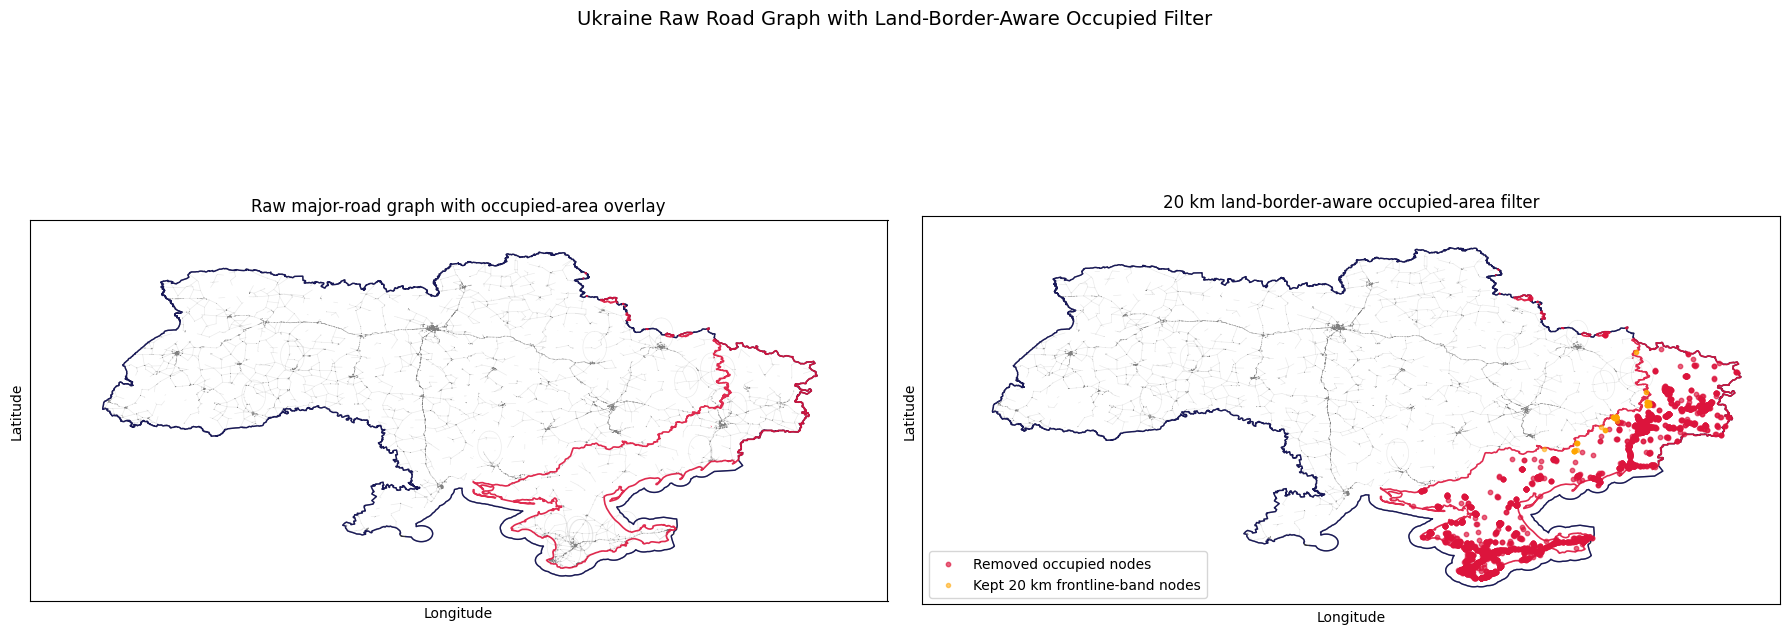

In [3]:
# ── Current occupied-territory filter with land-only border rule ────────
# Keep an occupied node only if it lies within 20 km of the inland
# Ukraine-facing occupied boundary. We derive a land-only Ukraine border from
# OSMnx by subtracting coastline-adjacent segments from the country outline.
# Coastline is treated as Russia/sea side and never creates forgiveness.

OCCUPIED_CACHE_GZ = PROJECT_ROOT / "data/deepstate-map-data.geojson.gz"
OCCUPIED_CACHE_GEOJSON = PROJECT_ROOT / "data/deepstate-map-data.geojson"
OCCUPIED_REMOTE_URL = "https://raw.githubusercontent.com/cyterat/deepstate-map-data/main/deepstate-map-data.geojson.gz"
COASTLINE_CACHE_GEOJSON = PROJECT_ROOT / "cache/ukraine_coastline.geojson"

FRONTLINE_KEEP_BAND_KM = 20.0
RUSSIA_SIDE_MATCH_KM = 20.0
COASTLINE_STRIP_KM = 3.0
BORDER_RISK_BUFFER_KM = 60.0

def polygon_parts(geom):
    if geom.is_empty:
        return []
    if geom.geom_type == "Polygon":
        return [geom]
    if geom.geom_type == "MultiPolygon":
        return list(geom.geoms)

    parts = []
    for g in getattr(geom, "geoms", []):
        if g.geom_type == "Polygon":
            parts.append(g)
        elif g.geom_type == "MultiPolygon":
            parts.extend(list(g.geoms))
    return parts

def load_current_occupied_gdf(cache_gz=OCCUPIED_CACHE_GZ, cache_geojson=OCCUPIED_CACHE_GEOJSON, remote_url=OCCUPIED_REMOTE_URL):
    cache_gz.parent.mkdir(parents=True, exist_ok=True)

    if cache_geojson.exists():
        occupied_all = gpd.read_file(cache_geojson)
    else:
        if not cache_gz.exists():
            print("Occupied-territory dataset not cached locally; downloading current snapshot dataset...")
            with urlopen(remote_url) as response, open(cache_gz, "wb") as out_f:
                shutil.copyfileobj(response, out_f)

        with gzip.open(cache_gz, "rb") as src, open(cache_geojson, "wb") as dst:
            shutil.copyfileobj(src, dst)
        occupied_all = gpd.read_file(cache_geojson)

    if occupied_all.crs is None:
        occupied_all = occupied_all.set_crs("EPSG:4326")
    else:
        occupied_all = occupied_all.to_crs("EPSG:4326")

    snapshot_date = None
    if "date" in occupied_all.columns:
        occupied_all["date"] = pd.to_datetime(occupied_all["date"], errors="coerce")
        valid_dates = occupied_all["date"].dropna()
        if not valid_dates.empty:
            snapshot_date = valid_dates.max()
            occupied_all = occupied_all[occupied_all["date"] == snapshot_date].copy()

    if occupied_all.empty:
        raise ValueError("Occupied-territory dataset did not contain any usable current geometry")

    occupied_geom = occupied_all.geometry.union_all() if hasattr(occupied_all.geometry, "union_all") else occupied_all.geometry.unary_union
    occupied_components = polygon_parts(occupied_geom)
    return occupied_all, snapshot_date, occupied_geom, occupied_components

def load_ukraine_land_border_and_coastline(coastline_cache=COASTLINE_CACHE_GEOJSON):
    ukraine_shape = ox.geocode_to_gdf("Ukraine")
    ukraine_geom = ukraine_shape.geometry.union_all() if hasattr(ukraine_shape.geometry, "union_all") else ukraine_shape.geometry.unary_union
    ukraine_metric = gpd.GeoSeries([ukraine_geom], crs="EPSG:4326").to_crs(3857).iloc[0]
    full_boundary_metric = ukraine_metric.boundary

    coastline_cache.parent.mkdir(parents=True, exist_ok=True)
    if coastline_cache.exists():
        coastline_gdf = gpd.read_file(coastline_cache)
    else:
        print("Downloading Ukraine coastline from OSM...")
        coastline_gdf = ox.features_from_place("Ukraine", tags={"natural": "coastline"}).copy()
        coastline_gdf = coastline_gdf[coastline_gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()
        coastline_gdf.to_file(coastline_cache, driver="GeoJSON")

    coastline_gdf = coastline_gdf.to_crs("EPSG:4326")
    coastline_metric = coastline_gdf.to_crs(3857)
    coastline_union_metric = coastline_metric.geometry.union_all() if hasattr(coastline_metric.geometry, "union_all") else coastline_metric.geometry.unary_union

    land_only_border_metric = full_boundary_metric.difference(coastline_union_metric.buffer(COASTLINE_STRIP_KM * 1000.0))
    return ukraine_shape, ukraine_geom, land_only_border_metric, coastline_union_metric

def build_forgiving_current_filter(G, occupied_geom, occupied_components, land_only_border_metric, coastline_metric):
    node_ids = list(G.nodes())
    node_points = gpd.GeoSeries(
        gpd.points_from_xy([G.nodes[n]["x"] for n in node_ids], [G.nodes[n]["y"] for n in node_ids]),
        index=node_ids,
        crs="EPSG:4326",
    )
    node_points_metric = node_points.to_crs(3857)
    inside_occupied = node_points.intersects(occupied_geom).to_dict()

    russia_side_reference_metric = land_only_border_metric.union(coastline_metric)
    russia_side_buffer_metric = russia_side_reference_metric.buffer(RUSSIA_SIDE_MATCH_KM * 1000.0)

    territory_frontline_distance_km = {n: np.inf for n in node_ids}
    territory_rear_distance_km = {n: np.inf for n in node_ids}
    territory_interior_depth_km = {n: 0.0 for n in node_ids}
    territory_cross_width_km = {n: np.inf for n in node_ids}
    territory_removal_threshold_km = {n: FRONTLINE_KEEP_BAND_KM for n in node_ids}
    territory_is_ukraine_side = {n: False for n in node_ids}
    frontline_boundaries_metric = []

    for poly in occupied_components:
        poly_nodes = [n for n in node_ids if inside_occupied[n] and node_points.loc[n].intersects(poly)]
        if not poly_nodes:
            continue

        poly_metric = gpd.GeoSeries([poly], crs="EPSG:4326").to_crs(3857).iloc[0]
        poly_boundary = poly_metric.boundary
        rear_boundary = poly_boundary.intersection(russia_side_buffer_metric)
        frontline_boundary = poly_boundary.difference(russia_side_buffer_metric)

        if rear_boundary.is_empty:
            rear_boundary = poly_boundary
        if not frontline_boundary.is_empty:
            frontline_boundaries_metric.append(frontline_boundary)

        if frontline_boundary.is_empty:
            poly_front_dists = {n: float("inf") for n in poly_nodes}
        else:
            poly_front_dists = {
                n: float(node_points_metric.loc[n].distance(frontline_boundary) / 1000.0)
                for n in poly_nodes
            }
        poly_rear_dists = {
            n: float(node_points_metric.loc[n].distance(rear_boundary) / 1000.0)
            for n in poly_nodes
        }

        finite_cross_widths = [
            poly_front_dists[n] + poly_rear_dists[n]
            for n in poly_nodes
            if np.isfinite(poly_front_dists[n]) and np.isfinite(poly_rear_dists[n])
        ]
        component_cross_width_km = max(finite_cross_widths) if finite_cross_widths else np.inf

        for n in poly_nodes:
            territory_frontline_distance_km[n] = poly_front_dists[n]
            territory_rear_distance_km[n] = poly_rear_dists[n]
            territory_interior_depth_km[n] = poly_front_dists[n]
            territory_cross_width_km[n] = component_cross_width_km
            territory_is_ukraine_side[n] = np.isfinite(poly_front_dists[n]) and (poly_front_dists[n] <= poly_rear_dists[n])

    if frontline_boundaries_metric:
        frontline_boundary_metric = gpd.GeoSeries(frontline_boundaries_metric, crs=3857).union_all() if hasattr(gpd.GeoSeries(frontline_boundaries_metric, crs=3857), "union_all") else gpd.GeoSeries(frontline_boundaries_metric, crs=3857).unary_union
    else:
        frontline_boundary_metric = gpd.GeoSeries([occupied_geom], crs="EPSG:4326").to_crs(3857).boundary.iloc[0]

    border_distance_km = {}
    for n in node_ids:
        if inside_occupied[n]:
            border_distance_km[n] = territory_frontline_distance_km[n]
        else:
            border_distance_km[n] = float(node_points_metric.loc[n].distance(frontline_boundary_metric) / 1000.0)

    removed_occupied_nodes = [
        n for n in node_ids
        if inside_occupied[n]
        and (
            not territory_is_ukraine_side[n]
            or not np.isfinite(territory_frontline_distance_km[n])
            or territory_frontline_distance_km[n] > FRONTLINE_KEEP_BAND_KM
        )
    ]
    removed_russia_side_nodes = [
        n for n in node_ids
        if inside_occupied[n] and (not territory_is_ukraine_side[n])
    ]

    border_proximity = {
        n: max(0.0, 1.0 - min(border_distance_km[n], BORDER_RISK_BUFFER_KM) / BORDER_RISK_BUFFER_KM)
        for n in node_ids
    }
    territory_border_risk = {}
    for n in node_ids:
        if inside_occupied[n]:
            if territory_is_ukraine_side[n] and np.isfinite(territory_frontline_distance_km[n]):
                inside_pressure = min(1.0, territory_frontline_distance_km[n] / FRONTLINE_KEEP_BAND_KM)
                territory_border_risk[n] = min(1.0, 0.55 + 0.45 * inside_pressure)
            else:
                territory_border_risk[n] = 1.0
        else:
            territory_border_risk[n] = 0.85 * border_proximity[n]

    G_filtered = G.copy()
    G_filtered.remove_nodes_from(removed_occupied_nodes)
    isolated_nodes = [n for n, deg in dict(G_filtered.degree()).items() if deg == 0]
    G_filtered.remove_nodes_from(isolated_nodes)

    surviving_nodes = list(G_filtered.nodes())
    nx.set_node_attributes(G_filtered, {n: float(inside_occupied[n]) for n in surviving_nodes}, "territory_occupation_fraction")
    nx.set_node_attributes(G_filtered, {n: float(border_distance_km[n]) for n in surviving_nodes}, "territory_border_distance_km")
    nx.set_node_attributes(G_filtered, {n: float(territory_interior_depth_km[n]) for n in surviving_nodes}, "territory_interior_depth_km")
    nx.set_node_attributes(G_filtered, {n: float(territory_cross_width_km[n]) for n in surviving_nodes}, "territory_cross_width_km")
    nx.set_node_attributes(G_filtered, {n: float(territory_removal_threshold_km[n]) for n in surviving_nodes}, "territory_removal_threshold_km")
    nx.set_node_attributes(G_filtered, {n: float(territory_frontline_distance_km[n]) for n in surviving_nodes}, "territory_frontline_distance_km")
    nx.set_node_attributes(G_filtered, {n: float(territory_rear_distance_km[n]) for n in surviving_nodes}, "territory_rear_distance_km")
    nx.set_node_attributes(G_filtered, {n: bool(territory_is_ukraine_side[n]) for n in surviving_nodes}, "territory_is_ukraine_side")
    nx.set_node_attributes(G_filtered, {n: float(territory_border_risk[n]) for n in surviving_nodes}, "territory_border_risk")

    current_debug = {
        "inside_occupied": inside_occupied,
        "occupied_geom": occupied_geom,
        "border_distance_km": border_distance_km,
        "territory_frontline_distance_km": territory_frontline_distance_km,
        "territory_rear_distance_km": territory_rear_distance_km,
        "territory_interior_depth_km": territory_interior_depth_km,
        "territory_cross_width_km": territory_cross_width_km,
        "territory_removal_threshold_km": territory_removal_threshold_km,
        "territory_border_risk": territory_border_risk,
        "territory_is_ukraine_side": territory_is_ukraine_side,
        "removed_occupied_nodes": removed_occupied_nodes,
        "removed_russia_side_nodes": removed_russia_side_nodes,
    }
    return G_filtered, current_debug

occupied_current_gdf, occupied_snapshot_date, occupied_geom, occupied_components = load_current_occupied_gdf()
current_occupied_gs = gpd.GeoSeries([occupied_geom], crs="EPSG:4326")
ukraine_shape, ukraine_geom, land_only_border_metric, coastline_metric = load_ukraine_land_border_and_coastline()
land_only_border_gs = gpd.GeoSeries([land_only_border_metric], crs=3857).to_crs("EPSG:4326")

G_raw_current_filtered, current_filter_debug = build_forgiving_current_filter(
    G_raw,
    occupied_geom,
    occupied_components,
    land_only_border_metric,
    coastline_metric,
)

snapshot_label = occupied_snapshot_date.strftime("%Y-%m-%d") if occupied_snapshot_date is not None else "undated cached snapshot"
inside_frontline_dists = [
    v for n, v in current_filter_debug["territory_interior_depth_km"].items()
    if current_filter_debug["inside_occupied"][n] and np.isfinite(v)
]
print(f"Using occupied-territory snapshot: {snapshot_label}")
print(f"Forgiving occupied band: {FRONTLINE_KEEP_BAND_KM:.1f} km from the inland Ukraine-side occupied boundary")
print(f"Russia-side reference: land-only Ukraine border plus coastline, matched within {RUSSIA_SIDE_MATCH_KM:.1f} km")
print(f"Raw graph:                {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")
print(f"Filtered graph:           {G_raw_current_filtered.number_of_nodes()} nodes, {G_raw_current_filtered.number_of_edges()} edges")
print(f"Removed occupied nodes total: {len(current_filter_debug['removed_occupied_nodes'])}")
print(f"Removed Russia-side occupied nodes: {len(current_filter_debug['removed_russia_side_nodes'])}")
if inside_frontline_dists:
    print(
        f"Frontline distance inside occupied territory (km): min={min(inside_frontline_dists):.3f}, "
        f"mean={np.mean(inside_frontline_dists):.3f}, max={max(inside_frontline_dists):.3f}"
    )

base_sample = ox.convert.to_undirected(G_raw)
if base_sample.number_of_nodes() > 0:
    base_sample = base_sample.subgraph(max(nx.connected_components(base_sample), key=len)).copy()

filtered_sample = ox.convert.to_undirected(G_raw_current_filtered)
if filtered_sample.number_of_nodes() > 0:
    filtered_sample = filtered_sample.subgraph(max(nx.connected_components(filtered_sample), key=len)).copy()

base_pos = {n: (d["x"], d["y"]) for n, d in base_sample.nodes(data=True)}
filtered_pos = {n: (d["x"], d["y"]) for n, d in filtered_sample.nodes(data=True)}

removed_nodes = [n for n in current_filter_debug["removed_occupied_nodes"] if n in base_sample.nodes()]
kept_occupied_nodes = [
    n for n in filtered_sample.nodes()
    if filtered_sample.nodes[n].get("territory_occupation_fraction", 0.0) > 0.5
]
removed_pos = {n: base_pos[n] for n in removed_nodes}
kept_occupied_pos = {n: filtered_pos[n] for n in kept_occupied_nodes}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, graph, pos, title in [
    (axes[0], base_sample, base_pos, "Raw major-road graph with occupied-area overlay"),
    (axes[1], filtered_sample, filtered_pos, "20 km land-border-aware occupied-area filter"),
]:
    ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
    land_only_border_gs.plot(ax=ax, color="navy", linewidth=1.0, alpha=0.5, zorder=2)
    current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.2, alpha=0.9, zorder=3)
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color="gray", alpha=0.16, width=0.5)

    if ax is axes[1] and removed_pos:
        ax.scatter(
            [removed_pos[n][0] for n in removed_nodes],
            [removed_pos[n][1] for n in removed_nodes],
            s=10,
            c="crimson",
            alpha=0.65,
            zorder=4,
            label="Removed occupied nodes",
        )

    if ax is axes[1] and kept_occupied_pos:
        ax.scatter(
            [kept_occupied_pos[n][0] for n in kept_occupied_nodes],
            [kept_occupied_pos[n][1] for n in kept_occupied_nodes],
            s=9,
            c="orange",
            alpha=0.55,
            zorder=5,
            label="Kept 20 km frontline-band nodes",
        )

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="lower left")

plt.suptitle("Ukraine Raw Road Graph with Land-Border-Aware Occupied Filter", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/current_occupied_filter_forgiving.png", dpi=150, bbox_inches="tight")
plt.show()


demand_raw not found; rebuilding demand nodes from ACLED using k-medoids...
Rebuilt demand_raw with 15 demand nodes (k-medoids, k=15).
Using G_raw_current_filtered as the adaptive-coarsening base graph.
Snapped 15 demand centroids to nearest graph nodes on G_raw_current_filtered.
Mapped 14 snapped demand nodes onto surviving coarse nodes for plotting.
Adaptive coarsening parameters:
  eps_near = 0.15
  eps_mid = 0.25
  eps_far = 0.4
  near_radius = 0.5
  mid_radius = 1.5

Raw-node zone counts:
  near: 2790 raw nodes
  mid: 6704 raw nodes
  far: 10694 raw nodes

Adaptive coarse-node zone counts:
  near: 67 coarse nodes
  mid: 43 coarse nodes
  far: 6 coarse nodes
Adaptive coarsening: 116 nodes, 203 edges
Abstracted path counts per coarse edge: min=2, mean=3.66, max=84

Top coarse edges by abstracted path count:
  Edge (105, 111): paths=84, travel_time=0.00 hr
  Edge (82, 111): paths=24, travel_time=0.09 hr
  Edge (72, 111): paths=20, travel_time=0.01 hr
  Edge (48, 73): paths=12, travel

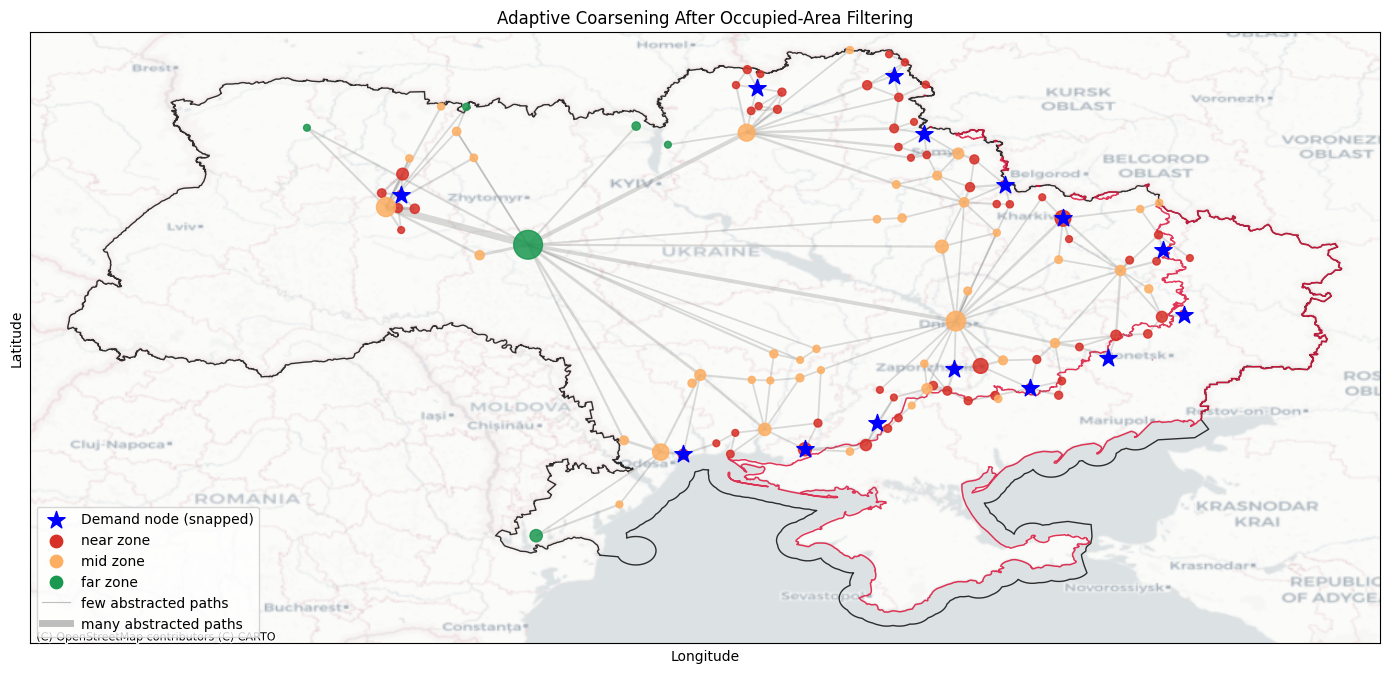

In [4]:
import contextily as ctx
from sklearn.cluster import DBSCAN

def cluster_demand_kmedoids(coords, n_clusters, random_state=42, max_iter=8, candidate_cap=200):
    coords = np.asarray(coords, dtype=float)
    n_samples = len(coords)
    if n_samples == 0:
        raise ValueError("cluster_demand_kmedoids needs at least one point")
    if n_clusters > n_samples:
        raise ValueError("n_clusters cannot exceed the number of points")

    rng = np.random.default_rng(random_state)
    medoid_indices = [int(rng.integers(n_samples))]
    closest_dist = ((coords - coords[medoid_indices[0]]) ** 2).sum(axis=1)

    for _ in range(1, n_clusters):
        total = closest_dist.sum()
        if total <= 0:
            remaining = np.setdiff1d(np.arange(n_samples), np.array(medoid_indices), assume_unique=False)
            next_idx = int(rng.choice(remaining))
        else:
            probs = closest_dist / total
            next_idx = int(rng.choice(n_samples, p=probs))
            while next_idx in medoid_indices:
                next_idx = int(rng.choice(n_samples, p=probs))
        medoid_indices.append(next_idx)
        new_dist = ((coords - coords[next_idx]) ** 2).sum(axis=1)
        closest_dist = np.minimum(closest_dist, new_dist)

    medoid_indices = np.array(medoid_indices, dtype=int)

    for _ in range(max_iter):
        medoids = coords[medoid_indices]
        dist_to_medoids = ((coords[:, None, :] - medoids[None, :, :]) ** 2).sum(axis=2)
        labels = dist_to_medoids.argmin(axis=1)
        updated = medoid_indices.copy()

        for k in range(n_clusters):
            cluster_idx = np.where(labels == k)[0]
            if len(cluster_idx) == 0:
                fallback = int(np.argmax(np.min(dist_to_medoids, axis=1)))
                updated[k] = fallback
                continue

            cluster_points = coords[cluster_idx]
            if len(cluster_idx) > candidate_cap:
                centroid = cluster_points.mean(axis=0)
                order = np.argsort(((cluster_points - centroid) ** 2).sum(axis=1))
                near_count = min(candidate_cap // 2, len(cluster_idx))
                chosen_local = order[:near_count]
                remaining = np.setdiff1d(np.arange(len(cluster_idx)), chosen_local, assume_unique=False)
                extra_count = min(candidate_cap - len(chosen_local), len(remaining))
                if extra_count > 0:
                    extra_local = rng.choice(remaining, size=extra_count, replace=False)
                    chosen_local = np.unique(np.concatenate([chosen_local, extra_local]))
                candidate_idx = cluster_idx[chosen_local]
            else:
                candidate_idx = cluster_idx

            candidate_points = coords[candidate_idx]
            candidate_costs = ((cluster_points[:, None, :] - candidate_points[None, :, :]) ** 2).sum(axis=2).sum(axis=0)
            updated[k] = int(candidate_idx[int(np.argmin(candidate_costs))])

        if np.array_equal(updated, medoid_indices):
            break
        medoid_indices = updated

    final_medoids = coords[medoid_indices]
    final_dist = ((coords[:, None, :] - final_medoids[None, :, :]) ** 2).sum(axis=2)
    labels = final_dist.argmin(axis=1)
    return labels, medoid_indices

def build_demand_nodes_kmedoids(df, n_clusters, random_state=42, candidate_cap=200):
    working = df.copy()
    coords = working[["latitude", "longitude"]].to_numpy(dtype=float)
    labels, medoid_indices = cluster_demand_kmedoids(
        coords,
        n_clusters=n_clusters,
        random_state=random_state,
        candidate_cap=candidate_cap,
    )
    working["cluster"] = labels

    medoid_lookup = {
        cluster_id: {
            "lat": float(coords[medoid_indices[cluster_id], 0]),
            "lon": float(coords[medoid_indices[cluster_id], 1]),
        }
        for cluster_id in range(n_clusters)
    }

    demand_raw = (
        working.groupby("cluster")
        .agg(
            n_events=("event_type", "count"),
            total_fatalities=("fatalities", "sum"),
        )
        .reset_index()
    )
    demand_raw["lat"] = demand_raw["cluster"].map(lambda c: medoid_lookup[c]["lat"])
    demand_raw["lon"] = demand_raw["cluster"].map(lambda c: medoid_lookup[c]["lon"])
    demand_raw = demand_raw[["lat", "lon", "n_events", "total_fatalities"]].reset_index(drop=True)
    return working, demand_raw, medoid_indices

if "demand_raw" not in globals():
    print("demand_raw not found; rebuilding demand nodes from ACLED using k-medoids...")
    acled_path = PROJECT_ROOT / "data/ACLED Data_2026-03-25.csv"
    if not acled_path.exists():
        raise FileNotFoundError(f"Could not find ACLED data at {acled_path}")

    acled_df = pd.read_csv(acled_path)
    acled_df = acled_df[
        (acled_df["country"] == "Ukraine")
        & (acled_df["year"] >= 2022)
        & (acled_df["event_type"].isin([
            "Explosions/Remote violence",
            "Battles",
            "Violence against civilians",
        ]))
    ].copy()

    n_demand = globals().get("N_DEMAND", 15)
    acled_df, demand_raw, demand_medoid_indices = build_demand_nodes_kmedoids(
        acled_df,
        n_clusters=n_demand,
        random_state=42,
        candidate_cap=200,
    )
    print(f"Rebuilt demand_raw with {len(demand_raw)} demand nodes (k-medoids, k={n_demand}).")

def adaptive_coarsen_graph(
    G,
    demand_points,
    eps_near=0.12,
    eps_mid=0.22,
    eps_far=0.40,
    near_radius=0.18,
    mid_radius=0.55,
):
    if hasattr(demand_points, "loc"):
        demand_coords = demand_points[["lat", "lon"]].to_numpy(dtype=float)
    else:
        demand_coords = np.asarray(demand_points, dtype=float)

    if len(demand_coords) == 0:
        raise ValueError("adaptive_coarsen_graph needs at least one demand point")

    node_ids = list(G.nodes())
    coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in node_ids], dtype=float)

    node_to_demand_dist = {}
    zone_to_nodes = {"near": [], "mid": [], "far": []}
    for i, n in enumerate(node_ids):
        dist = np.sqrt(((demand_coords - coords[i]) ** 2).sum(axis=1)).min()
        node_to_demand_dist[n] = float(dist)
        if dist <= near_radius:
            zone_to_nodes["near"].append(n)
        elif dist <= mid_radius:
            zone_to_nodes["mid"].append(n)
        else:
            zone_to_nodes["far"].append(n)

    zone_eps = {"near": eps_near, "mid": eps_mid, "far": eps_far}
    node_to_cluster = {}
    cluster_info = {}
    cluster_id = 0

    for zone in ["near", "mid", "far"]:
        zone_nodes = zone_to_nodes[zone]
        if not zone_nodes:
            continue

        zone_coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in zone_nodes], dtype=float)
        labels = DBSCAN(eps=zone_eps[zone], min_samples=1).fit(zone_coords).labels_

        for label in sorted(set(labels)):
            members = [zone_nodes[i] for i, lab in enumerate(labels) if lab == label]
            cid = cluster_id
            cluster_id += 1

            for n in members:
                node_to_cluster[n] = cid

            centroid_lat = float(np.mean([G.nodes[n]["y"] for n in members]))
            centroid_lon = float(np.mean([G.nodes[n]["x"] for n in members]))
            rep_node = min(
                members,
                key=lambda n: (G.nodes[n]["y"] - centroid_lat) ** 2 + (G.nodes[n]["x"] - centroid_lon) ** 2,
            )
            rep_lat = float(G.nodes[rep_node]["y"])
            rep_lon = float(G.nodes[rep_node]["x"])

            cluster_info[cid] = {
                "zone": zone,
                "lat": rep_lat,
                "lon": rep_lon,
                "centroid_lat": centroid_lat,
                "centroid_lon": centroid_lon,
                "rep_node": rep_node,
                "member_count": len(members),
                "mean_demand_dist": float(np.mean([node_to_demand_dist[n] for n in members])),
                "territory_occupation_fraction": float(np.mean([G.nodes[n].get("territory_occupation_fraction", 0.0) for n in members])),
                "territory_border_risk": float(max([G.nodes[n].get("territory_border_risk", 0.0) for n in members])),
                "territory_border_distance_km": float(min([G.nodes[n].get("territory_border_distance_km", float("inf")) for n in members])),
                "territory_frontline_distance_km": float(min([G.nodes[n].get("territory_frontline_distance_km", float("inf")) for n in members])),
                "territory_interior_depth_km": float(max([G.nodes[n].get("territory_interior_depth_km", 0.0) for n in members])),
            }

    CG_adaptive = nx.Graph()
    for cid, attrs in cluster_info.items():
        CG_adaptive.add_node(cid, **attrs)

    routing_graph = ox.convert.to_undirected(G)

    def path_metrics_on_road_graph(graph, source, target):
        path = nx.shortest_path(graph, source, target, weight="travel_time")
        total_time = 0.0
        total_length = 0.0
        for a, b in zip(path[:-1], path[1:]):
            edge_bundle = graph.get_edge_data(a, b)
            if edge_bundle is None:
                raise nx.NetworkXNoPath(f"Missing edge data for segment {(a, b)}")

            if isinstance(edge_bundle, dict) and all(isinstance(k, int) for k in edge_bundle.keys()):
                candidates = list(edge_bundle.values())
            else:
                candidates = [edge_bundle]

            finite_candidates = [
                d for d in candidates
                if np.isfinite(d.get("travel_time", np.nan)) and np.isfinite(d.get("length", np.nan))
            ]
            if finite_candidates:
                best = min(finite_candidates, key=lambda d: float(d.get("travel_time", np.inf)))
            else:
                best = min(candidates, key=lambda d: float(d.get("travel_time", np.inf)))

            total_time += float(best.get("travel_time", np.nan))
            total_length += float(best.get("length", np.nan))

        return float(total_time), float(total_length)

    edge_aggregates = {}
    for u, v, data in G.edges(data=True):
        cu = node_to_cluster.get(u)
        cv = node_to_cluster.get(v)
        if cu is None or cv is None or cu == cv:
            continue
        key = tuple(sorted((cu, cv)))
        agg = edge_aggregates.setdefault(key, {"travel_times": [], "lengths": [], "count": 0})
        agg["count"] += 1
        agg["travel_times"].append(float(data.get("travel_time", np.nan)))
        agg["lengths"].append(float(data.get("length", np.nan)))

    for (cu, cv), agg in edge_aggregates.items():
        rep_u = cluster_info[cu]["rep_node"]
        rep_v = cluster_info[cv]["rep_node"]
        finite_boundary_times = [t for t in agg["travel_times"] if np.isfinite(t)]
        finite_boundary_lengths = [l for l in agg["lengths"] if np.isfinite(l)]

        try:
            rep_travel_time, rep_length_m = path_metrics_on_road_graph(routing_graph, rep_u, rep_v)
        except (nx.NetworkXNoPath, nx.NodeNotFound, ValueError):
            rep_travel_time = float(np.nanmedian(finite_boundary_times)) if finite_boundary_times else float("inf")
            rep_length_m = float(np.nanmedian(finite_boundary_lengths)) if finite_boundary_lengths else float("inf")

        CG_adaptive.add_edge(
            cu,
            cv,
            travel_time=rep_travel_time,
            length_m=rep_length_m,
            abstracted_path_count=agg["count"],
            boundary_time_min_s=float(np.nanmin(finite_boundary_times)) if finite_boundary_times else float("inf"),
            boundary_time_mean_s=float(np.nanmean(finite_boundary_times)) if finite_boundary_times else float("inf"),
            boundary_time_median_s=float(np.nanmedian(finite_boundary_times)) if finite_boundary_times else float("inf"),
            boundary_length_min_m=float(np.nanmin(finite_boundary_lengths)) if finite_boundary_lengths else float("inf"),
            boundary_length_mean_m=float(np.nanmean(finite_boundary_lengths)) if finite_boundary_lengths else float("inf"),
            boundary_length_median_m=float(np.nanmedian(finite_boundary_lengths)) if finite_boundary_lengths else float("inf"),
        )

    CG_adaptive = CG_adaptive.subgraph(max(nx.connected_components(CG_adaptive), key=len)).copy()
    surviving_clusters = set(CG_adaptive.nodes())
    node_to_cluster = {n: cid for n, cid in node_to_cluster.items() if cid in surviving_clusters}
    return CG_adaptive, node_to_demand_dist, zone_to_nodes, node_to_cluster

adaptive_params = {
    "eps_near": 0.15,
    "eps_mid": 0.25,
    "eps_far": 0.40,
    "near_radius": 0.50,
    "mid_radius": 1.50,
}

adaptive_base_graph = G_raw_current_filtered if "G_raw_current_filtered" in globals() else G_raw
adaptive_base_name = "G_raw_current_filtered" if "G_raw_current_filtered" in globals() else "G_raw"
print(f"Using {adaptive_base_name} as the adaptive-coarsening base graph.")

demand_raw = demand_raw.copy()
demand_raw["centroid_lat"] = demand_raw["lat"]
demand_raw["centroid_lon"] = demand_raw["lon"]
snapped_nodes = ox.distance.nearest_nodes(
    adaptive_base_graph,
    X=demand_raw["lon"].to_list(),
    Y=demand_raw["lat"].to_list(),
)
demand_raw["graph_node"] = snapped_nodes
demand_raw["lat"] = [adaptive_base_graph.nodes[n]["y"] for n in snapped_nodes]
demand_raw["lon"] = [adaptive_base_graph.nodes[n]["x"] for n in snapped_nodes]
print(f"Snapped {len(demand_raw)} demand centroids to nearest graph nodes on {adaptive_base_name}.")

CG_adaptive, raw_dist_to_demand, raw_zone_membership, raw_node_to_cluster = adaptive_coarsen_graph(
    adaptive_base_graph,
    demand_raw[["lat", "lon"]],
    **adaptive_params,
)

demand_raw["coarse_node"] = demand_raw["graph_node"].map(raw_node_to_cluster)
demand_raw = demand_raw[demand_raw["coarse_node"].notna()].copy()
demand_raw["coarse_node"] = demand_raw["coarse_node"].astype(int)
demand_raw["plot_lat"] = demand_raw["coarse_node"].map(lambda n: CG_adaptive.nodes[n]["lat"])
demand_raw["plot_lon"] = demand_raw["coarse_node"].map(lambda n: CG_adaptive.nodes[n]["lon"])
print(f"Mapped {len(demand_raw)} snapped demand nodes onto surviving coarse nodes for plotting.")

print("Adaptive coarsening parameters:")
for k, v in adaptive_params.items():
    print(f"  {k} = {v}")

print("\nRaw-node zone counts:")
for zone in ["near", "mid", "far"]:
    print(f"  {zone}: {len(raw_zone_membership[zone])} raw nodes")

adaptive_zone_counts = pd.Series([CG_adaptive.nodes[n]["zone"] for n in CG_adaptive.nodes()]).value_counts()
print("\nAdaptive coarse-node zone counts:")
for zone in ["near", "mid", "far"]:
    print(f"  {zone}: {int(adaptive_zone_counts.get(zone, 0))} coarse nodes")

print(f"Adaptive coarsening: {CG_adaptive.number_of_nodes()} nodes, {CG_adaptive.number_of_edges()} edges")

edge_path_counts = [d["abstracted_path_count"] for _, _, d in CG_adaptive.edges(data=True)]
print(
    f"Abstracted path counts per coarse edge: min={min(edge_path_counts)}, "
    f"mean={np.mean(edge_path_counts):.2f}, max={max(edge_path_counts)}"
)

top_supported_edges = sorted(
    CG_adaptive.edges(data=True),
    key=lambda e: e[2]["abstracted_path_count"],
    reverse=True,
)[:8]
print("\nTop coarse edges by abstracted path count:")
for u, v, data in top_supported_edges:
    print(
        f"  Edge ({u}, {v}): paths={data['abstracted_path_count']}, "
        f"travel_time={data['travel_time'] / 3600:.2f} hr, "
        f"road_dist={data.get('length_m', float('nan')) / 1000:.1f} km"
    )

zone_colors = {"near": "#d73027", "mid": "#fdae61", "far": "#1a9850"}
adaptive_pos = {n: (d["lon"], d["lat"]) for n, d in CG_adaptive.nodes(data=True)}
minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)
try:
    ctx.add_basemap(
        ax,
        crs="EPSG:4326",
        source=ctx.providers.CartoDB.Positron,
        zoom=6,
        alpha=0.8,
    )
except Exception as exc:
    print(f"Basemap unavailable for adaptive plot, continuing without tiles: {exc}")

ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.1, alpha=0.85, zorder=2)

edge_list = list(CG_adaptive.edges(data=True))
edge_widths = [
    0.6 + 4.4 * np.sqrt(edge_data["abstracted_path_count"]) / np.sqrt(max(edge_path_counts))
    for _, _, edge_data in edge_list
]
edge_collection = nx.draw_networkx_edges(
    CG_adaptive,
    adaptive_pos,
    ax=ax,
    edgelist=[(u, v) for u, v, _ in edge_list],
    alpha=0.28,
    edge_color="gray",
    width=edge_widths,
)
edge_collection.set_zorder(3)

adaptive_sizes = [20 + 4 * np.sqrt(CG_adaptive.nodes[n]["member_count"]) for n in CG_adaptive.nodes()]
adaptive_colors = [zone_colors[CG_adaptive.nodes[n]["zone"]] for n in CG_adaptive.nodes()]
node_collection = nx.draw_networkx_nodes(
    CG_adaptive,
    adaptive_pos,
    ax=ax,
    node_size=adaptive_sizes,
    node_color=adaptive_colors,
    alpha=0.85,
)
node_collection.set_zorder(4)

demand_plot = demand_raw.drop_duplicates(subset=["coarse_node"])
demand_x = demand_plot["plot_lon"].to_list()
demand_y = demand_plot["plot_lat"].to_list()
ax.scatter(demand_x, demand_y, marker="*", c="blue", s=170, zorder=5, label="Demand node (snapped)")

for zone in ["near", "mid", "far"]:
    ax.scatter([], [], c=zone_colors[zone], s=80, label=f"{zone} zone")
ax.plot([], [], color="gray", linewidth=0.8, alpha=0.5, label="few abstracted paths")
ax.plot([], [], color="gray", linewidth=5.0, alpha=0.5, label="many abstracted paths")

ax.set_title("Adaptive Coarsening After Occupied-Area Filtering")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/adaptive_coarsening_after_occupied_filter.png", dpi=150, bbox_inches="tight")
plt.show()


Computing betweenness centrality on CG_adaptive (may take a moment)...

a_i: min=1.97, mean=6.86, max=10.00
b_i: min=1.83, mean=6.79, max=10.00
Demand proximity penalty is mild: min=0.000, mean=0.772, max=1.000
Occupied threat penalty is strong: min=0.000, mean=0.139, max=0.971

Top 5 cheapest nodes to open:
  Node 111: a_i=1.968, b_i=1.829, members=10456, demand_proximity=0.157, occupied_threat=0.000, edge_support=186
  Node 72: a_i=3.689, b_i=4.14, members=1957, demand_proximity=0.682, occupied_threat=0.024, edge_support=86
  Node 105: a_i=4.277, b_i=4.318, members=1733, demand_proximity=0.625, occupied_threat=0.000, edge_support=136
  Node 82: a_i=4.653, b_i=4.863, members=1013, demand_proximity=0.647, occupied_threat=0.000, edge_support=70
  Node 70: a_i=5.783, b_i=5.758, members=102, demand_proximity=0.575, occupied_threat=0.000, edge_support=34


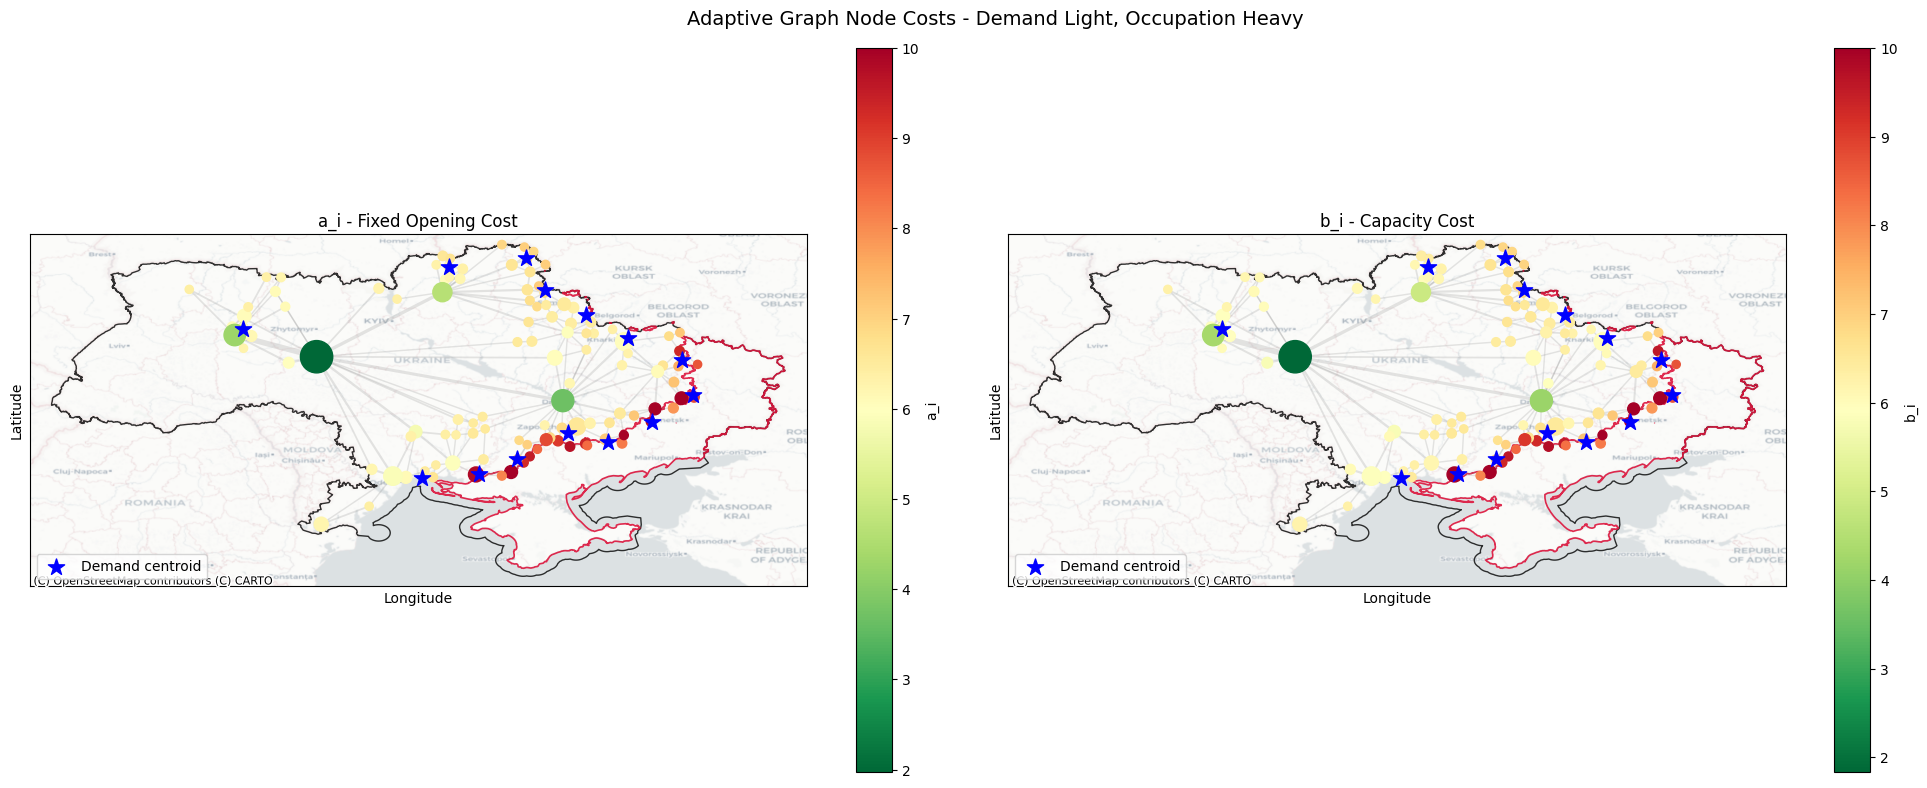

In [5]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ── a_i / b_i on the adaptive graph ─────────────────────────────────────
# Demand proximity now matters only a little.
# Occupied-territory proximity matters a lot.

degree = dict(CG_adaptive.degree())
print("Computing betweenness centrality on CG_adaptive (may take a moment)...")
centrality = nx.betweenness_centrality(CG_adaptive, weight="travel_time", normalized=True)

member_count = {n: CG_adaptive.nodes[n].get("member_count", 1) for n in CG_adaptive.nodes()}
mean_demand_dist = {n: CG_adaptive.nodes[n].get("mean_demand_dist", 0.0) for n in CG_adaptive.nodes()}
territory_border_risk = {n: CG_adaptive.nodes[n].get("territory_border_risk", 0.0) for n in CG_adaptive.nodes()}
territory_occupation_fraction = {n: CG_adaptive.nodes[n].get("territory_occupation_fraction", 0.0) for n in CG_adaptive.nodes()}
territory_frontline_distance_km = {n: CG_adaptive.nodes[n].get("territory_frontline_distance_km", np.inf) for n in CG_adaptive.nodes()}
incident_edge_support = {
    n: sum(data.get("abstracted_path_count", 1) for _, _, data in CG_adaptive.edges(n, data=True))
    for n in CG_adaptive.nodes()
}

large_hub_threshold = np.quantile(list(member_count.values()), 0.75)
large_hub_ids = [n for n, m in member_count.items() if m >= large_hub_threshold]
if not large_hub_ids:
    large_hub_ids = list(CG_adaptive.nodes())

def dist_to_large_hub(CG, node, hub_ids):
    node_lat = CG.nodes[node]["lat"]
    node_lon = CG.nodes[node]["lon"]
    dists = []
    for h in hub_ids:
        if h == node:
            continue
        h_lat = CG.nodes[h]["lat"]
        h_lon = CG.nodes[h]["lon"]
        base_dist = ((node_lat - h_lat) ** 2 + (node_lon - h_lon) ** 2) ** 0.5
        hub_scale = np.sqrt(CG.nodes[h].get("member_count", 1))
        dists.append(base_dist / hub_scale)
    return min(dists) if dists else 0.0

large_hub_dist = {n: dist_to_large_hub(CG_adaptive, n, large_hub_ids) for n in CG_adaptive.nodes()}

def normalize(d):
    vals = np.array(list(d.values()), dtype=float)
    finite_vals = vals[np.isfinite(vals)]
    if len(finite_vals) == 0:
        return {k: 0.5 for k in d}
    mn, mx = finite_vals.min(), finite_vals.max()
    if mx == mn:
        return {k: 0.5 for k in d}
    out = {}
    for k, v in d.items():
        vv = mx if not np.isfinite(v) else float(v)
        out[k] = (vv - mn) / (mx - mn)
    return out

norm_degree = normalize(degree)
norm_centrality = normalize(centrality)
norm_member = normalize(member_count)
norm_large_hub_dist = normalize(large_hub_dist)
norm_incident_support = normalize(incident_edge_support)
norm_demand_dist = normalize(mean_demand_dist)
norm_occ_frontline_dist = normalize(territory_frontline_distance_km)

large_hub_proximity = {n: 1 - norm_large_hub_dist[n] for n in CG_adaptive.nodes()}
demand_proximity = {n: 1 - norm_demand_dist[n] for n in CG_adaptive.nodes()}
occupied_proximity = {n: 1 - norm_occ_frontline_dist[n] for n in CG_adaptive.nodes()}
occupied_threat = {
    n: min(1.0, 0.65 * occupied_proximity[n] + 0.25 * territory_border_risk[n] + 0.10 * territory_occupation_fraction[n])
    for n in CG_adaptive.nodes()
}

node_params = {}
for n in CG_adaptive.nodes():
    demand_penalty = 0.06 * demand_proximity[n]
    occupied_penalty = 0.42 * occupied_threat[n]
    a_score = min(1.0, (
        0.16 * (1 - norm_degree[n])
      + 0.12 * (1 - norm_centrality[n])
      + 0.16 * (1 - norm_member[n])
      + 0.10 * (1 - large_hub_proximity[n])
      + 0.10 * (1 - norm_incident_support[n])
      + demand_penalty
      + occupied_penalty
    ))
    b_score = min(1.0, (
        0.18 * (1 - norm_centrality[n])
      + 0.16 * (1 - norm_member[n])
      + 0.12 * (1 - large_hub_proximity[n])
      + 0.18 * (1 - norm_incident_support[n])
      + 0.04 * demand_proximity[n]
      + 0.46 * occupied_threat[n]
    ))
    node_params[n] = {
        "a_i": round(1 + 9 * a_score, 3),
        "b_i": round(1 + 9 * b_score, 3),
    }

nx.set_node_attributes(CG_adaptive, {n: vals["a_i"] for n, vals in node_params.items()}, "a_i")
nx.set_node_attributes(CG_adaptive, {n: vals["b_i"] for n, vals in node_params.items()}, "b_i")
nx.set_node_attributes(CG_adaptive, degree, "degree")
nx.set_node_attributes(CG_adaptive, centrality, "betweenness_centrality")
nx.set_node_attributes(CG_adaptive, member_count, "member_count")
nx.set_node_attributes(CG_adaptive, mean_demand_dist, "mean_demand_dist")
nx.set_node_attributes(CG_adaptive, territory_frontline_distance_km, "territory_frontline_distance_km")
nx.set_node_attributes(CG_adaptive, territory_border_risk, "territory_border_risk")
nx.set_node_attributes(CG_adaptive, territory_occupation_fraction, "territory_occupation_fraction")
nx.set_node_attributes(CG_adaptive, incident_edge_support, "incident_edge_support")
nx.set_node_attributes(CG_adaptive, occupied_threat, "occupied_threat")

a_vals = [v["a_i"] for v in node_params.values()]
b_vals = [v["b_i"] for v in node_params.values()]
print(f"\na_i: min={min(a_vals):.2f}, mean={np.mean(a_vals):.2f}, max={max(a_vals):.2f}")
print(f"b_i: min={min(b_vals):.2f}, mean={np.mean(b_vals):.2f}, max={max(b_vals):.2f}")
print(
    f"Demand proximity penalty is mild: min={min(demand_proximity.values()):.3f}, "
    f"mean={np.mean(list(demand_proximity.values())):.3f}, max={max(demand_proximity.values()):.3f}"
)
print(
    f"Occupied threat penalty is strong: min={min(occupied_threat.values()):.3f}, "
    f"mean={np.mean(list(occupied_threat.values())):.3f}, max={max(occupied_threat.values()):.3f}"
)

sorted_by_a = sorted(node_params.items(), key=lambda x: x[1]["a_i"])
print("\nTop 5 cheapest nodes to open:")
for n, p in sorted_by_a[:5]:
    print(
        f"  Node {n}: a_i={p['a_i']}, b_i={p['b_i']}, "
        f"members={member_count[n]}, demand_proximity={demand_proximity[n]:.3f}, "
        f"occupied_threat={occupied_threat[n]:.3f}, edge_support={incident_edge_support[n]}"
    )

edge_list = list(CG_adaptive.edges(data=True))
edge_path_counts = [d.get("abstracted_path_count", 1) for _, _, d in edge_list]
edge_widths = [
    0.5 + 3.5 * np.sqrt(edge_data.get("abstracted_path_count", 1)) / np.sqrt(max(edge_path_counts))
    for _, _, edge_data in edge_list
]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, cost_key, title in zip(
    axes,
    ["a_i", "b_i"],
    ["a_i - Fixed Opening Cost", "b_i - Capacity Cost"],
):
    costs = [node_params[n][cost_key] for n in CG_adaptive.nodes()]
    norm = mcolors.Normalize(vmin=min(costs), vmax=max(costs))
    cmap = cm.RdYlGn_r

    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    try:
        ctx.add_basemap(
            ax,
            crs="EPSG:4326",
            source=ctx.providers.CartoDB.Positron,
            zoom=6,
            alpha=0.8,
        )
    except Exception as exc:
        print(f"Basemap unavailable for {cost_key}, continuing without tiles: {exc}")

    ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
    current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.2, alpha=0.9, zorder=2)
    edge_collection = nx.draw_networkx_edges(
        CG_adaptive,
        adaptive_pos,
        ax=ax,
        edgelist=[(u, v) for u, v, _ in edge_list],
        edge_color="gray",
        alpha=0.20,
        width=edge_widths,
    )
    edge_collection.set_zorder(3)

    node_collection = nx.draw_networkx_nodes(
        CG_adaptive,
        adaptive_pos,
        ax=ax,
        node_color=costs,
        cmap=cmap,
        node_size=[30 + 5 * np.sqrt(member_count[n]) for n in CG_adaptive.nodes()],
        vmin=min(costs),
        vmax=max(costs),
    )
    node_collection.set_zorder(4)

    demand_x = [row["lon"] for _, row in demand_raw.iterrows()]
    demand_y = [row["lat"] for _, row in demand_raw.iterrows()]
    ax.scatter(demand_x, demand_y, marker="*", c="blue", s=150, zorder=5, label="Demand centroid")

    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=cost_key)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="lower left")

plt.suptitle("Adaptive Graph Node Costs - Demand Light, Occupation Heavy", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/adaptive_cost_structure.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Land-only Ukraine background comparison (new cell, does not modify earlier logic) ──
# Build a land-only polygon using coastline geometry plus road-network reference points,
# then compare it against the default OSMnx country polygon that includes sea area.

from shapely.geometry import box
from shapely.ops import polygonize, unary_union

def build_land_only_background_from_coastline(country_geom, coastline_metric, land_reference_graph, frame_pad_km=150.0, sample_size=600):
    country_metric = gpd.GeoSeries([country_geom], crs="EPSG:4326").to_crs(3857).iloc[0]
    minx, miny, maxx, maxy = country_metric.bounds
    frame = box(
        minx - frame_pad_km * 1000.0,
        miny - frame_pad_km * 1000.0,
        maxx + frame_pad_km * 1000.0,
        maxy + frame_pad_km * 1000.0,
    )

    coastline_clipped = coastline_metric.intersection(frame)
    linework = [frame.boundary]
    if not coastline_clipped.is_empty:
        linework.append(coastline_clipped)

    polygon_candidates = list(polygonize(unary_union(linework)))
    if not polygon_candidates:
        raise ValueError("Could not polygonize coastline into land/sea candidate regions")

    ref_nodes = list(land_reference_graph.nodes())
    if len(ref_nodes) > sample_size:
        keep_idx = np.linspace(0, len(ref_nodes) - 1, sample_size, dtype=int)
        ref_nodes = [ref_nodes[i] for i in keep_idx]

    land_points_metric = gpd.GeoSeries(
        gpd.points_from_xy(
            [land_reference_graph.nodes[n]["x"] for n in ref_nodes],
            [land_reference_graph.nodes[n]["y"] for n in ref_nodes],
        ),
        crs="EPSG:4326",
    ).to_crs(3857)
    land_points_union = land_points_metric.union_all() if hasattr(land_points_metric, "union_all") else land_points_metric.unary_union

    land_pieces = []
    for poly in polygon_candidates:
        clipped = poly.intersection(country_metric)
        if clipped.is_empty or clipped.area <= 0:
            continue
        if clipped.buffer(500.0).intersects(land_points_union):
            land_pieces.append(clipped)

    if not land_pieces:
        raise ValueError("Failed to identify any land-only polygon pieces from coastline segmentation")

    land_metric = unary_union(land_pieces).intersection(country_metric)
    if land_metric.geom_type == "GeometryCollection":
        land_metric = unary_union([g for g in land_metric.geoms if g.geom_type in ["Polygon", "MultiPolygon"]])

    return gpd.GeoSeries([land_metric], crs=3857).to_crs("EPSG:4326")

ukraine_land_only_background_gs = build_land_only_background_from_coastline(
    ukraine_geom,
    coastline_metric,
    G_raw,
)
ukraine_land_only_background_shape = gpd.GeoDataFrame(geometry=ukraine_land_only_background_gs, crs="EPSG:4326")

full_area_km2 = gpd.GeoSeries([ukraine_geom], crs="EPSG:4326").to_crs(3857).area.iloc[0] / 1_000_000.0
land_only_area_km2 = ukraine_land_only_background_gs.to_crs(3857).area.iloc[0] / 1_000_000.0
sea_removed_km2 = max(full_area_km2 - land_only_area_km2, 0.0)

print("Land-only background comparison")
print("-" * 60)
print(f"OSMnx Ukraine polygon area (includes sea): {full_area_km2:,.0f} km^2")
print(f"Derived land-only background area:        {land_only_area_km2:,.0f} km^2")
print(f"Removed sea-area portion:                 {sea_removed_km2:,.0f} km^2")

compare_graph = ox.convert.to_undirected(G_raw)
if compare_graph.number_of_nodes() > 0:
    compare_graph = compare_graph.subgraph(max(nx.connected_components(compare_graph), key=len)).copy()
compare_pos = {n: (d["x"], d["y"]) for n, d in compare_graph.nodes(data=True)}

minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, bg_layer, title in [
    (axes[0], ukraine_shape, "Default OSMnx polygon (includes sea area)"),
    (axes[1], ukraine_land_only_background_shape, "Derived land-only Ukraine background"),
]:
    bg_layer.plot(ax=ax, facecolor="#efe6d5", edgecolor="black", linewidth=1.0, alpha=0.95, zorder=1)
    nx.draw_networkx_edges(compare_graph, compare_pos, ax=ax, edge_color="gray", alpha=0.12, width=0.35)
    current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.0, alpha=0.85, zorder=3)
    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle("Ukraine Background Comparison: Maritime-Including vs Land-Only", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/ukraine_land_only_background_compare.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Alternative land-only background using the road-network footprint ──
# This avoids the maritime wedge issue by deriving a land mask from the actual
# road-network footprint rather than the OSM admin polygon.

from shapely import concave_hull as shapely_concave_hull
from shapely.geometry import MultiPoint

def build_land_only_background_from_roads(road_graph, country_geom, sample_size=5000, hull_ratio=0.03, coast_buffer_km=12.0):
    road_nodes = list(road_graph.nodes())
    if len(road_nodes) > sample_size:
        keep_idx = np.linspace(0, len(road_nodes) - 1, sample_size, dtype=int)
        road_nodes = [road_nodes[i] for i in keep_idx]

    road_points = MultiPoint([(road_graph.nodes[n]["x"], road_graph.nodes[n]["y"]) for n in road_nodes])
    hull = shapely_concave_hull(road_points, ratio=hull_ratio, allow_holes=False)

    hull_metric = gpd.GeoSeries([hull], crs="EPSG:4326").to_crs(3857).iloc[0]
    country_metric = gpd.GeoSeries([country_geom], crs="EPSG:4326").to_crs(3857).iloc[0]

    # Expand slightly so coastal/border roads do not make the land mask too tight,
    # then clip back to the Ukraine polygon to stay inside the country extent.
    land_metric = hull_metric.buffer(coast_buffer_km * 1000.0).intersection(country_metric)
    return gpd.GeoSeries([land_metric], crs=3857).to_crs("EPSG:4326")

ukraine_land_only_roads_gs = build_land_only_background_from_roads(
    G_raw,
    ukraine_geom,
    sample_size=5000,
    hull_ratio=0.03,
    coast_buffer_km=12.0,
)
ukraine_land_only_roads_shape = gpd.GeoDataFrame(geometry=ukraine_land_only_roads_gs, crs="EPSG:4326")

full_area_km2 = gpd.GeoSeries([ukraine_geom], crs="EPSG:4326").to_crs(3857).area.iloc[0] / 1_000_000.0
roads_land_area_km2 = ukraine_land_only_roads_gs.to_crs(3857).area.iloc[0] / 1_000_000.0
roads_removed_km2 = max(full_area_km2 - roads_land_area_km2, 0.0)

print("Road-footprint land-only background")
print("-" * 60)
print(f"OSMnx Ukraine polygon area (includes sea): {full_area_km2:,.0f} km^2")
print(f"Road-footprint land-only area:            {roads_land_area_km2:,.0f} km^2")
print(f"Removed sea-area portion:                 {roads_removed_km2:,.0f} km^2")

compare_graph = ox.convert.to_undirected(G_raw)
if compare_graph.number_of_nodes() > 0:
    compare_graph = compare_graph.subgraph(max(nx.connected_components(compare_graph), key=len)).copy()
compare_pos = {n: (d["x"], d["y"]) for n, d in compare_graph.nodes(data=True)}

minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, bg_layer, title in [
    (axes[0], ukraine_shape, "Default OSMnx polygon (includes sea area)"),
    (axes[1], ukraine_land_only_roads_shape, "Road-footprint-derived land-only background"),
]:
    bg_layer.plot(ax=ax, facecolor="#efe6d5", edgecolor="black", linewidth=1.0, alpha=0.95, zorder=1)
    nx.draw_networkx_edges(compare_graph, compare_pos, ax=ax, edge_color="gray", alpha=0.12, width=0.35)
    current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.0, alpha=0.85, zorder=3)
    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle("Ukraine Background Comparison: Default Polygon vs Road-Footprint Land Mask", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/ukraine_land_only_background_compare_roads.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Natural Earth land-only country background (new comparison cell) ──
# Natural Earth provides country polygons and land boundary lines directly,
# which is much simpler than trying to infer land from the OSM admin polygon.

import zipfile

NE_COUNTRIES_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
NE_LAND_BORDERS_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_boundary_lines_land.zip"
NE_COUNTRIES_ZIP = PROJECT_ROOT / "cache/ne_10m_admin_0_countries.zip"
NE_BORDERS_ZIP = PROJECT_ROOT / "cache/ne_10m_admin_0_boundary_lines_land.zip"
NE_COUNTRIES_DIR = PROJECT_ROOT / "cache/ne_10m_admin_0_countries"
NE_BORDERS_DIR = PROJECT_ROOT / "cache/ne_10m_admin_0_boundary_lines_land"

def ensure_zip_downloaded(url, zip_path):
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print(f"Downloading {zip_path.name} from Natural Earth...")
        with urlopen(url) as response, open(zip_path, "wb") as out_f:
            shutil.copyfileobj(response, out_f)

def ensure_zip_extracted(zip_path, extract_dir):
    extract_dir.mkdir(parents=True, exist_ok=True)
    shp_files = list(extract_dir.glob("*.shp"))
    if shp_files:
        return shp_files[0]
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    shp_files = list(extract_dir.glob("*.shp"))
    if not shp_files:
        raise FileNotFoundError(f"No shapefile found after extracting {zip_path}")
    return shp_files[0]

ensure_zip_downloaded(NE_COUNTRIES_URL, NE_COUNTRIES_ZIP)
ensure_zip_downloaded(NE_LAND_BORDERS_URL, NE_BORDERS_ZIP)
countries_shp = ensure_zip_extracted(NE_COUNTRIES_ZIP, NE_COUNTRIES_DIR)
borders_shp = ensure_zip_extracted(NE_BORDERS_ZIP, NE_BORDERS_DIR)

ne_countries = gpd.read_file(countries_shp).to_crs("EPSG:4326")
ne_borders = gpd.read_file(borders_shp).to_crs("EPSG:4326")

ukraine_ne = ne_countries[
    (ne_countries.get("ADMIN") == "Ukraine")
    | (ne_countries.get("SOVEREIGNT") == "Ukraine")
    | (ne_countries.get("NAME") == "Ukraine")
].copy()
if ukraine_ne.empty:
    raise ValueError("Could not find Ukraine in Natural Earth countries layer")

ukraine_ne_land_gs = gpd.GeoSeries([ukraine_ne.geometry.union_all() if hasattr(ukraine_ne.geometry, 'union_all') else ukraine_ne.geometry.unary_union], crs="EPSG:4326")
ukraine_ne_land_shape = gpd.GeoDataFrame(geometry=ukraine_ne_land_gs, crs="EPSG:4326")

ukraine_ne_land_border = ne_borders[
    (ne_borders.get("ADM0_LEFT") == "Ukraine")
    | (ne_borders.get("ADM0_RIGHT") == "Ukraine")
    | (ne_borders.get("SOV_A3") == "UKR")
    | (ne_borders.get("BRK_A3") == "UKR")
].copy()

osm_area_km2 = gpd.GeoSeries([ukraine_geom], crs="EPSG:4326").to_crs(3857).area.iloc[0] / 1_000_000.0
ne_area_km2 = ukraine_ne_land_gs.to_crs(3857).area.iloc[0] / 1_000_000.0
removed_km2 = max(osm_area_km2 - ne_area_km2, 0.0)

print("Natural Earth land-only background")
print("-" * 60)
print(f"OSMnx Ukraine polygon area (includes sea): {osm_area_km2:,.0f} km^2")
print(f"Natural Earth land-only area:             {ne_area_km2:,.0f} km^2")
print(f"Removed sea-area portion:                 {removed_km2:,.0f} km^2")

compare_graph = ox.convert.to_undirected(G_raw)
if compare_graph.number_of_nodes() > 0:
    compare_graph = compare_graph.subgraph(max(nx.connected_components(compare_graph), key=len)).copy()
compare_pos = {n: (d["x"], d["y"]) for n, d in compare_graph.nodes(data=True)}

minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, bg_layer, title, show_ne_land_border in [
    (axes[0], ukraine_shape, "Default OSMnx polygon (includes sea area)", False),
    (axes[1], ukraine_ne_land_shape, "Natural Earth land-only country polygon", True),
]:
    bg_layer.plot(ax=ax, facecolor="#efe6d5", edgecolor="black", linewidth=1.0, alpha=0.95, zorder=1)
    nx.draw_networkx_edges(compare_graph, compare_pos, ax=ax, edge_color="gray", alpha=0.12, width=0.35)
    if show_ne_land_border and not ukraine_ne_land_border.empty:
        ukraine_ne_land_border.plot(ax=ax, color="navy", linewidth=1.0, alpha=0.8, zorder=2)
    current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.0, alpha=0.85, zorder=3)
    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle("Ukraine Background Comparison: OSM Polygon vs Natural Earth Land-Only Polygon", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/ukraine_land_only_background_compare_natural_earth.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Diagnostic plot: adaptive graph with coarse-edge travel times and routed road distances ──
# Uses the Natural Earth land-only background if that comparison cell has already been run.


bg_layer = ukraine_ne_land_shape if "ukraine_ne_land_shape" in globals() else ukraine_shape
plot_title_suffix = "(Natural Earth land-only background)" if "ukraine_ne_land_shape" in globals() else "(default background)"

fig, ax = plt.subplots(figsize=(18, 10))
bg_layer.plot(ax=ax, facecolor="#efe6d5", edgecolor="black", linewidth=1.0, alpha=0.95, zorder=1)
if "current_occupied_gs" in globals():
    current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.1, alpha=0.9, zorder=2)

pos = {n: (CG_adaptive.nodes[n]["lon"], CG_adaptive.nodes[n]["lat"]) for n in CG_adaptive.nodes()}
edge_list = list(CG_adaptive.edges(data=True))
edge_path_counts = [d.get("abstracted_path_count", 1) for _, _, d in edge_list] or [1]
edge_widths = [
    0.6 + 4.4 * np.sqrt(d.get("abstracted_path_count", 1)) / np.sqrt(max(edge_path_counts))
    for _, _, d in edge_list
]

edge_collection = nx.draw_networkx_edges(
    CG_adaptive,
    pos,
    ax=ax,
    edgelist=[(u, v) for u, v, _ in edge_list],
    edge_color="gray",
    alpha=0.30,
    width=edge_widths,
)
edge_collection.set_zorder(3)

zone_colors = {"near": "#d73027", "mid": "#fdae61", "far": "#1a9850"}
node_colors = [zone_colors.get(CG_adaptive.nodes[n].get("zone", "mid"), "#999999") for n in CG_adaptive.nodes()]
node_sizes = [20 + 4 * np.sqrt(CG_adaptive.nodes[n].get("member_count", 1)) for n in CG_adaptive.nodes()]
node_collection = nx.draw_networkx_nodes(
    CG_adaptive,
    pos,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.85,
    linewidths=0.2,
    edgecolors="white",
)
node_collection.set_zorder(4)

if "demand_nodes" in globals() and len(demand_nodes) > 0:
    ax.scatter(
        demand_nodes["plot_lon"],
        demand_nodes["plot_lat"],
        marker="*",
        c="royalblue",
        s=140,
        zorder=6,
        label="Demand centroid",
    )

edge_labels = {}
for u, v, data in edge_list:
    travel_hr = data.get("travel_time", np.nan) / 3600.0 if np.isfinite(data.get("travel_time", np.nan)) else np.nan
    road_km = data.get("length_m", np.nan) / 1000.0 if np.isfinite(data.get("length_m", np.nan)) else np.nan
    travel_str = f"{travel_hr:.2f}h" if np.isfinite(travel_hr) else "NAh"
    road_str = f"{road_km:.0f}km road" if np.isfinite(road_km) else "NA road"
    edge_labels[(u, v)] = f"{travel_str}\n{road_str}"

nx.draw_networkx_edge_labels(
    CG_adaptive,
    pos,
    edge_labels=edge_labels,
    ax=ax,
    font_size=6,
    rotate=False,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.70, "pad": 0.15},
)

minx, miny, maxx, maxy = bg_layer.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)
ax.set_title(f"Adaptive Coarsening with Edge Travel Times and Routed Road Distances {plot_title_suffix}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/adaptive_coarsening_edge_labels.png", dpi=170, bbox_inches="tight")
plt.show()


Adaptive node side classification from saved data
------------------------------------------------------------
Nodes loaded: 112
Ukraine side (1): 101
Russia side (0):  11
Stored-vs-geometry mismatches: 11


,node,stored_flag,geom_flag,lon,lat,frontline_km
10,102,1,0,37.687656,48.415423,0.176451
0,2,1,0,33.445024,46.771407,0.337738
8,88,1,0,36.943674,50.276808,1.185490
6,52,1,0,34.906614,47.387045,1.559931
3,32,1,0,34.321958,51.874336,1.843595
9,101,1,0,37.635132,50.195361,2.841232
4,42,1,0,35.293352,47.456871,2.884360
7,84,1,0,35.130290,51.169145,3.002220
1,6,1,0,33.932096,47.141080,4.386003
5,51,1,0,36.854894,48.035864,6.238117


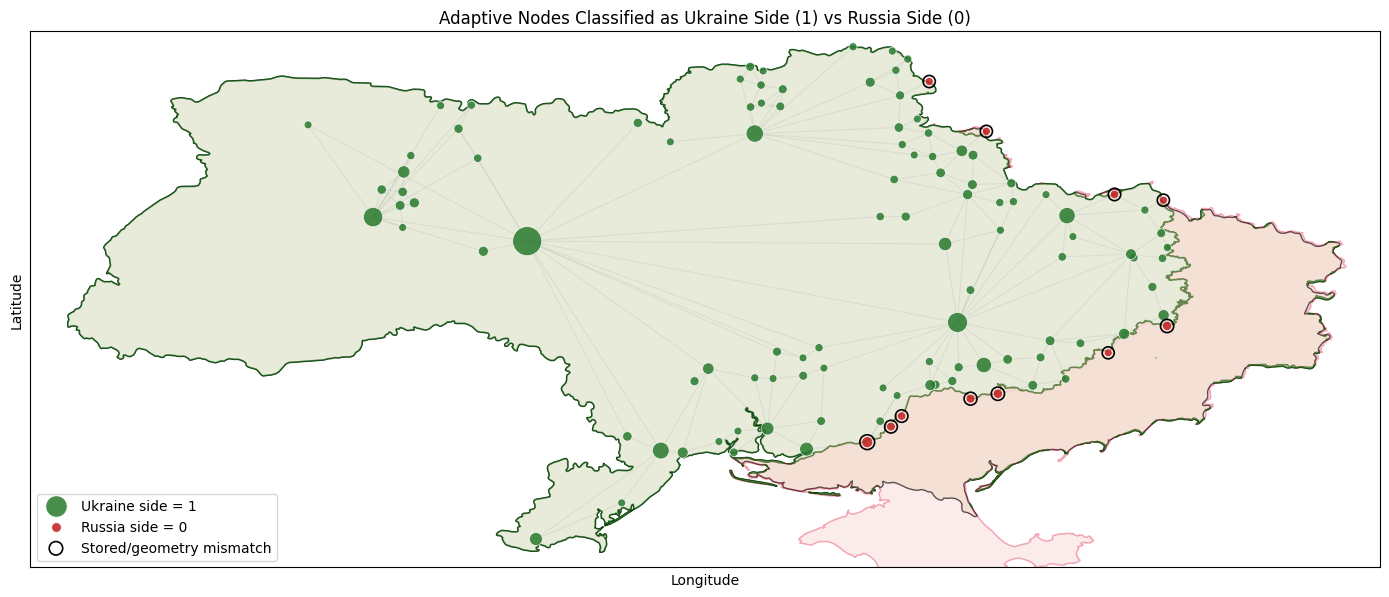

In [10]:
# ── Self-contained diagnostic: adaptive node 0/1 Ukraine-side flag from data/ ──
# This cell loads everything directly from data/ and cache/ so it can run on its own.

import gzip
import json as pyjson
import shutil
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from urllib.request import urlopen

ADAPTIVE_GRAPH_PATH = PROJECT_ROOT / "data/synthetic/ukraine_adaptive_coarse.graphml"
OCCUPIED_CACHE_GZ = PROJECT_ROOT / "data/cache/deepstate-map-data.geojson.gz"
OCCUPIED_CACHE_GEOJSON = PROJECT_ROOT / "data/cache/deepstate-map-data.geojson"
OCCUPIED_REMOTE_URL = "https://raw.githubusercontent.com/cyterat/deepstate-map-data/main/deepstate-map-data.geojson.gz"
NE_COUNTRIES_ZIP = PROJECT_ROOT / "data/cache/ne_10m_admin_0_countries.zip"
NE_COUNTRIES_DIR = PROJECT_ROOT / "data/cache/ne_10m_admin_0_countries"
NE_COUNTRIES_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"

if not ADAPTIVE_GRAPH_PATH.exists():
    raise FileNotFoundError(f"Could not find adaptive graph at {ADAPTIVE_GRAPH_PATH}. Build the synthetic data first.")


def ensure_zip_downloaded(url, zip_path):
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print(f"Downloading {zip_path.name}...")
        with urlopen(url) as response, open(zip_path, "wb") as out_f:
            shutil.copyfileobj(response, out_f)


def ensure_zip_extracted(zip_path, extract_dir):
    extract_dir.mkdir(parents=True, exist_ok=True)
    shp_files = sorted(extract_dir.glob("*.shp"))
    if shp_files:
        return shp_files[0]
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    shp_files = sorted(extract_dir.glob("*.shp"))
    if not shp_files:
        raise FileNotFoundError(f"No shapefile found after extracting {zip_path}")
    return shp_files[0]


def load_current_occupied_geom(cache_gz=OCCUPIED_CACHE_GZ, cache_geojson=OCCUPIED_CACHE_GEOJSON, remote_url=OCCUPIED_REMOTE_URL):
    cache_gz.parent.mkdir(parents=True, exist_ok=True)
    if cache_geojson.exists():
        occupied_all = gpd.read_file(cache_geojson)
    else:
        if not cache_gz.exists():
            print("Downloading occupied-territory snapshot...")
            with urlopen(remote_url) as response, open(cache_gz, "wb") as out_f:
                shutil.copyfileobj(response, out_f)
        with gzip.open(cache_gz, "rb") as src, open(cache_geojson, "wb") as dst:
            shutil.copyfileobj(src, dst)
        occupied_all = gpd.read_file(cache_geojson)

    occupied_all = occupied_all.set_crs("EPSG:4326") if occupied_all.crs is None else occupied_all.to_crs("EPSG:4326")
    if "date" in occupied_all.columns:
        occupied_all["date"] = pd.to_datetime(occupied_all["date"], errors="coerce")
        valid_dates = occupied_all["date"].dropna()
        if not valid_dates.empty:
            occupied_all = occupied_all[occupied_all["date"] == valid_dates.max()].copy()

    occupied_geom = occupied_all.geometry.union_all() if hasattr(occupied_all.geometry, "union_all") else occupied_all.geometry.unary_union
    return occupied_all, occupied_geom


ensure_zip_downloaded(NE_COUNTRIES_URL, NE_COUNTRIES_ZIP)
countries_shp = ensure_zip_extracted(NE_COUNTRIES_ZIP, NE_COUNTRIES_DIR)
ne_countries = gpd.read_file(countries_shp).to_crs("EPSG:4326")

ukraine_ne = ne_countries[
    (ne_countries.get("ADMIN") == "Ukraine")
    | (ne_countries.get("SOVEREIGNT") == "Ukraine")
    | (ne_countries.get("NAME") == "Ukraine")
].copy()
if ukraine_ne.empty:
    raise ValueError("Could not find Ukraine in Natural Earth countries layer")

ukraine_land_geom = ukraine_ne.geometry.union_all() if hasattr(ukraine_ne.geometry, "union_all") else ukraine_ne.geometry.unary_union
ukraine_land_shape = gpd.GeoDataFrame(geometry=[ukraine_land_geom], crs="EPSG:4326")
occupied_gdf, occupied_geom = load_current_occupied_geom()
occupied_gs = gpd.GeoSeries([occupied_geom], crs="EPSG:4326")

ukraine_land_metric = gpd.GeoSeries([ukraine_land_geom], crs="EPSG:4326").to_crs(3857).iloc[0]
occupied_metric = occupied_gs.to_crs(3857).iloc[0]
sovereign_metric = ukraine_land_metric.difference(occupied_metric)
sovereign_geom = gpd.GeoSeries([sovereign_metric], crs=3857).to_crs("EPSG:4326").iloc[0]
sovereign_shape = gpd.GeoDataFrame(geometry=[sovereign_geom], crs="EPSG:4326")
sovereign_buffer_metric = sovereign_metric.buffer(1000.0)

CG = nx.read_graphml(ADAPTIVE_GRAPH_PATH)

node_ids = list(CG.nodes())
node_lon = [float(CG.nodes[n]["lon"]) for n in node_ids]
node_lat = [float(CG.nodes[n]["lat"]) for n in node_ids]
node_points = gpd.GeoSeries(gpd.points_from_xy(node_lon, node_lat), index=node_ids, crs="EPSG:4326")
node_points_metric = node_points.to_crs(3857)

ukraine_side_flag = {n: int(node_points_metric.loc[n].intersects(sovereign_buffer_metric)) for n in node_ids}
russia_side_flag = {n: 1 - ukraine_side_flag[n] for n in node_ids}

stored_flag = {
    n: int(bool(pyjson.loads(CG.nodes[n]["territory_is_ukraine_side"].lower()) if isinstance(CG.nodes[n].get("territory_is_ukraine_side"), str) and CG.nodes[n].get("territory_is_ukraine_side").lower() in {"true", "false"} else CG.nodes[n].get("territory_is_ukraine_side", False)))
    for n in node_ids
}
mismatch_flag = {n: int(stored_flag[n] != ukraine_side_flag[n]) for n in node_ids}

print("Adaptive node side classification from saved data")
print("-" * 60)
print(f"Nodes loaded: {len(node_ids)}")
print(f"Ukraine side (1): {sum(ukraine_side_flag.values())}")
print(f"Russia side (0):  {sum(russia_side_flag.values())}")
print(f"Stored-vs-geometry mismatches: {sum(mismatch_flag.values())}")

if any(mismatch_flag.values()):
    mismatch_df = pd.DataFrame([
        {
            "node": n,
            "stored_flag": stored_flag[n],
            "geom_flag": ukraine_side_flag[n],
            "lon": float(CG.nodes[n]["lon"]),
            "lat": float(CG.nodes[n]["lat"]),
            "frontline_km": float(CG.nodes[n].get("territory_frontline_distance_km", np.nan)),
        }
        for n in node_ids if mismatch_flag[n]
    ]).sort_values(["stored_flag", "geom_flag", "frontline_km"])
    display(mismatch_df)

pos = {n: (float(CG.nodes[n]["lon"]), float(CG.nodes[n]["lat"])) for n in node_ids}
member_sizes = [28 + 4 * np.sqrt(float(CG.nodes[n].get("member_count", 1))) for n in node_ids]
uk_nodes = [n for n in node_ids if ukraine_side_flag[n] == 1]
ru_nodes = [n for n in node_ids if ukraine_side_flag[n] == 0]
mismatch_nodes = [n for n in node_ids if mismatch_flag[n] == 1]

fig, ax = plt.subplots(figsize=(14, 9))
ukraine_land_shape.plot(ax=ax, facecolor="#f4eddc", edgecolor="black", linewidth=1.0, alpha=0.95, zorder=0)
occupied_gs.plot(ax=ax, facecolor="#f7c8c8", edgecolor="crimson", linewidth=1.1, alpha=0.35, zorder=0.5)
sovereign_shape.plot(ax=ax, facecolor="#dfead9", edgecolor="darkgreen", linewidth=1.2, alpha=0.55, zorder=0.8)
nx.draw_networkx_edges(CG, pos, ax=ax, edge_color="gray", alpha=0.14, width=0.7)

if uk_nodes:
    ax.scatter(
        [pos[n][0] for n in uk_nodes],
        [pos[n][1] for n in uk_nodes],
        s=[28 + 4 * np.sqrt(float(CG.nodes[n].get("member_count", 1))) for n in uk_nodes],
        c="#2e7d32",
        alpha=0.88,
        edgecolors="white",
        linewidths=0.5,
        zorder=3,
        label="Ukraine side = 1",
    )
if ru_nodes:
    ax.scatter(
        [pos[n][0] for n in ru_nodes],
        [pos[n][1] for n in ru_nodes],
        s=[28 + 4 * np.sqrt(float(CG.nodes[n].get("member_count", 1))) for n in ru_nodes],
        c="#c62828",
        alpha=0.90,
        edgecolors="white",
        linewidths=0.5,
        zorder=3.2,
        label="Russia side = 0",
    )
if mismatch_nodes:
    ax.scatter(
        [pos[n][0] for n in mismatch_nodes],
        [pos[n][1] for n in mismatch_nodes],
        s=[70 + 5 * np.sqrt(float(CG.nodes[n].get("member_count", 1))) for n in mismatch_nodes],
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=4,
        label="Stored/geometry mismatch",
    )

xmin, ymin, xmax, ymax = ukraine_land_shape.total_bounds
x_pad = (xmax - xmin) * 0.03
y_pad = (ymax - ymin) * 0.03
ax.set_xlim(xmin - x_pad, xmax + x_pad)
ax.set_ylim(ymin - y_pad, ymax + y_pad)
ax.set_title("Adaptive Nodes Classified as Ukraine Side (1) vs Russia Side (0)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/adaptive_node_side_flag_from_data.png", dpi=150, bbox_inches="tight")
plt.show()

